# Examples_MLIP: a tour of the results

What was done, why, and what came out, one module at a time. Every cell reads only files that
are committed: the CSVs and JSON the scripts wrote under `modules/*/outputs*/` and
`modules/story/`, the split manifests under `data/splits/`, and a few PNGs. No AM26 file,
checkpoint, GPU or CRISP checkout is needed, so the notebook runs from a plain clone, and CI
executes it on every push.

The repository README has the one-page summary. This notebook is for the reader who wants the
numbers behind each claim and the file each number comes from. Each section states the question,
what was done, what came out, and where the files are. The text quotes the numbers the cells
print, rounded. If a cell and the text ever disagree, the cell is right, because it is the file.

**Contents**

0. The map: modules, questions, files
1. The data and the splits
2. M0: three foundation models, no fine-tuning
3. M1: fine-tuning MACE-MPA-0 on AM26 silica and carbon, with the MD check, the melt-quench and the seed committee
4. M2: how many amorphous cells are enough?
5. M4: how clean are the reference forces?
6. What this does not show, and what comes next

## 0. The map

| Module | Question | Reads | Writes | README |
|---|---|---|---|---|
| M0 foundation triage | How far do MACE-MPA-0, MACE-MP-0b3 and MACE-MH-1 get on AM26 silica and carbon as they come, and does their disagreement follow their error? | the AM26 file | `modules/M0_foundation_triage/outputs*/metrics.csv`, `per_frame_*.csv`, `spread_vs_error_*.csv`, `run_summary.json` | `modules/M0_foundation_triage/README.md` |
| M1 fine-tune | Does MACE-MPA-0 fine-tuned on some AM26 cells transfer to cells it never saw, hold up in MD, and make a glass of its own? | the splits, the base model | `modules/M1_finetune_asio2/outputs/**/heldout_metrics.csv`, `md_stability/`, `melt_quench_5000K/` | `modules/M1_finetune_asio2/README.md` |
| M2 ensemble support | How many cells before density, coordination, pair distances and rings are resolved to a declared tolerance? | the AM26 cells, per quench rate or density | `modules/M2_ensemble_support/outputs/support_summary.csv`, `support_curve_*.csv` | `modules/M2_ensemble_support/README.md` |
| M3 Vitriflow baseline | Vitriflow's silica example as shipped, the classical baseline. Not started. | | | `modules/M3_vitriflow_baseline/README.md` |
| M4 label quality | How clean are the AM26 reference forces? | the AM26 file | `modules/M4_label_quality/outputs/net_force_*.csv` | `modules/M4_label_quality/README.md` |
| story | The figures for a talk, built from M1's melt-quench with CRISP | the melt-quench cells and trajectory | `modules/story/fig_*.png`, `*.csv`, `quench_video.mp4` | `modules/story/rings_zipper_crosscheck.md` |

The helpers behind the scripts live in `casebook/` (reading AM26, metrics, structure
descriptors, the support criterion), with their tests in `tests/`. `hpc/` holds the PBS
templates and the exact submissions. `CREDITS.md` names every dataset, model and method.
`tools/make_results_table.py` regenerates the README tables from the same CSVs this notebook
reads, with the same bootstrap function.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# the repository root is the nearest parent that holds pyproject.toml
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
if str(ROOT) not in sys.path:  # so the notebook also runs without `pip install -e .`
    sys.path.insert(0, str(ROOT))
from casebook.metrics import bootstrap_rmse  # the function tools/make_results_table.py uses as well


def load(rel):
    "A committed CSV, by its path relative to the repository root."
    return pd.read_csv(ROOT / rel)


def read_json(rel):
    return json.loads((ROOT / rel).read_text(encoding="utf-8"))


plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 10, "axes.titlesize": 11, "legend.frameon": False})
pd.set_option("display.precision", 3)
pd.set_option("display.width", 160)
ZS, FT = "#8c8c8c", "#c0392b"  # zero-shot grey and fine-tuned red, as in the story figures
M1 = "modules/M1_finetune_asio2/outputs"
print("repository root found; every path below is relative to it")

repository root found; every path below is relative to it


## 1. The data and the splits

**What.** AM26 (Fragapane and Deringer, 2026) is one extxyz file of melt-quenched cells with
PBE energies and forces: amorphous carbon at five densities, silica at four quench rates,
silicon, Li–P–S and Ge–Sb–Te, plus binary end-member cells. `data/get_am26.py` downloads it
and checks the SHA-256 recorded in `data/CHECKSUMS.json`. The systems are labelled from their
composition, because the file documents no metadata keys. The counts below come from the M4
audit, which touches every cell.

**Why it shaped the work.** There is no key named after the quench rate. The rate sits inside
the `label` field, as `silica-mq_10-13_7`. My first silica split therefore fell back to a
random hold-out, and the run meant as a reverse hold-out repeated it. Once the rate was parsed
out of the label with a regex, the two rate hold-outs were made as separate arms. All of this
is on record in the split manifests, which list every source index per split.

In [2]:
nf = load("modules/M4_label_quality/outputs/net_force_per_frame.csv")
cells = (nf.groupby("system").agg(cells=("frame", "size"), atoms_per_cell=("natoms", "median"))
           .sort_values("cells", ascending=False))
print(f"{len(nf)} cells in the AM26 file; the 'unknown:' rows are its binary end-member cells, labelled by composition")
cells.T

934 cells in the AM26 file; the 'unknown:' rows are its binary end-member cells, labelled by composition


system,a-Si,a-GST,a-C,a-LiPS,a-SiO2,unknown:GeTe,unknown:SbTe,unknown:LiS,unknown:PS
cells,324.0,210.0,100.0,100.0,80.0,40.0,40.0,20.0,20.0
atoms_per_cell,64.0,198.0,216.0,312.0,300.0,216.0,180.0,324.0,224.0


In [3]:
def held_out(m):
    v = m["heldout_group_value"]
    if m["split_type"] == "random":
        return "a random quarter"
    if isinstance(v, dict):
        lo, hi = v["density_range_g_cm3"]
        return f"densities {lo} to {hi} g/cm3"
    return f"10^{int(v)} K/s"


rows = []
for manifest in sorted((ROOT / "data/splits").glob("*/split_manifest.json")):
    m = json.loads(manifest.read_text(encoding="utf-8"))
    rows.append({"split": manifest.parent.name, "system": m["system"], "type": m["split_type"],
                 "held out": held_out(m), **m["counts"]})
pd.DataFrame(rows).set_index("split")

,system,type,held out,train,valid,test
split,,,,,,
a-C,a-C,density_band,densities 1.5 to 2.0 g/cm3,64,11,25
a-SiO2,a-SiO2,random,a random quarter,51,9,20
a-SiO2_holdmin,a-SiO2,random,a random quarter,51,9,20
a-SiO2_rate11,a-SiO2,group,10^11 K/s,51,9,20
a-SiO2_rate14,a-SiO2,group,10^14 K/s,51,9,20


`a-SiO2_holdmin` is the same random split as `a-SiO2`: that command ran before the rate key was
known, so the run trained on it is a repeat of arm A. The two `rate` splits hold out a whole
quench rate, twenty cells each, and the carbon split holds out the most porous quarter.

## 2. M0: three foundation models, no fine-tuning

**Question.** How far do current MACE foundation models get on the AM26 silica and carbon cells
as they come, and when the three disagree on a force, is that where they are also wrong?

**Why first.** It costs nothing but CPU time, it picks the base model for the fine-tune, and
the model-to-model spread is the cheapest uncertainty estimate available before any training.
MACE-MPA-0 and MACE-MP-0b3 are MIT. MACE-MH-1 is under the Academic Software License, so it
is evaluated and nothing is trained from it.

**What was done.** `modules/M0_foundation_triage/run.py` evaluates each model on every cell of
a system, on CPU in float64, with no dispersion correction. It writes the force and energy
errors per system and model, the error of every cell, and the per-atom force spread of the
three models against the error of their mean, with a Spearman coefficient. The remaining AM26
systems were run with the two MIT models into `outputs_other_systems/`.

In [4]:
m0 = pd.concat([load("modules/M0_foundation_triage/outputs/metrics.csv"),
                load("modules/M0_foundation_triage/outputs_other_systems/metrics.csv")], ignore_index=True)
rho = {}
for folder in ("outputs", "outputs_other_systems"):
    for system, v in read_json(f"modules/M0_foundation_triage/{folder}/run_summary.json")["systems"].items():
        rho[system] = v["spearman_rho_spread_vs_error"]


def offset_stats(system, model):
    "The mean energy offset of a model on a system, and the energy MAE once it is removed."
    folder = "outputs" if system in ("a-SiO2", "a-C") else "outputs_other_systems"
    e = load(f"modules/M0_foundation_triage/{folder}/per_frame_{system}_{model}.csv")["energy_error_meV_atom"]
    return pd.Series({"energy_offset_meV_atom": e.mean(), "energy_mae_offset_removed": (e - e.mean()).abs().mean()})


m0 = m0.join(m0.apply(lambda r: offset_stats(r["system"], r["model"]), axis=1))
m0["spearman_rho"] = m0["system"].map(rho)
m0[["system", "model", "licence", "n_frames", "force_rmse_meV_A", "force_rel_rmse_percent", "energy_mae_meV_atom",
    "energy_offset_meV_atom", "energy_mae_offset_removed", "sec_per_frame", "spearman_rho"]]

,system,model,licence,n_frames,force_rmse_meV_A,force_rel_rmse_percent,energy_mae_meV_atom,energy_offset_meV_atom,energy_mae_offset_removed,sec_per_frame,spearman_rho
0,a-SiO2,MACE-MPA-0,MIT,80,49.217,5.207,0.419,0.367,0.293,2.392,0.511
1,a-SiO2,MACE-MP-0b3,MIT,80,55.753,5.898,3.693,3.693,0.710,2.456,0.511
2,a-SiO2,MACE-MH-1,ASL,80,32.728,3.462,3.127,3.127,0.245,2.550,0.511
3,a-C,MACE-MPA-0,MIT,100,693.294,50.878,99.162,-99.162,13.375,1.935,0.410
4,a-C,MACE-MP-0b3,MIT,100,755.916,55.474,127.571,-127.571,16.444,2.170,0.410
5,a-C,MACE-MH-1,ASL,100,412.195,30.249,11.181,-6.244,10.018,3.321,0.410
6,a-Si,MACE-MPA-0,MIT,324,163.608,28.792,6.416,-2.447,6.261,0.844,0.210
7,a-Si,MACE-MP-0b3,MIT,324,203.646,35.838,29.146,28.907,8.849,0.502,0.210
8,a-LiPS,MACE-MPA-0,MIT,100,109.920,23.219,3.926,-1.559,3.530,1.453,0.509
9,a-LiPS,MACE-MP-0b3,MIT,100,136.799,28.897,21.032,-21.032,7.055,1.670,0.509


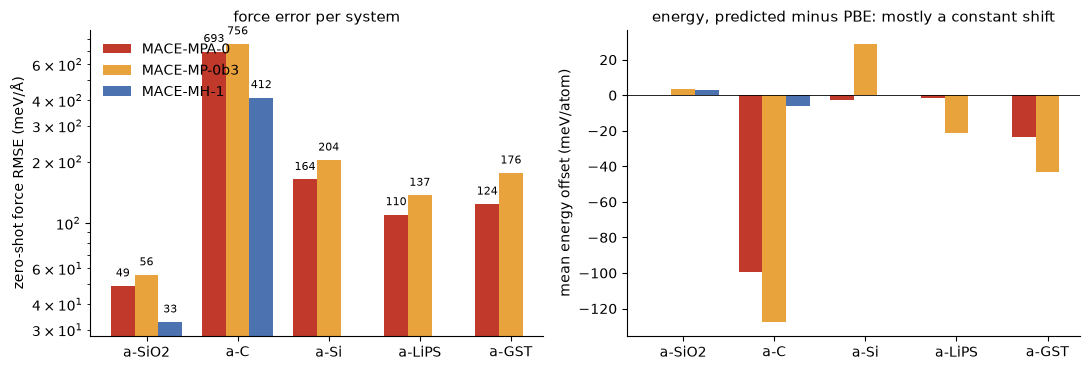

In [5]:
systems = ["a-SiO2", "a-C", "a-Si", "a-LiPS", "a-GST"]
models = ["MACE-MPA-0", "MACE-MP-0b3", "MACE-MH-1"]
colours = {"MACE-MPA-0": FT, "MACE-MP-0b3": "#e8a33d", "MACE-MH-1": "#4c72b0"}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
w = 0.26
for i, model in enumerate(models):
    sub = m0[m0["model"] == model].set_index("system")
    x = [systems.index(s) + (i - 1) * w for s in sub.index]
    axes[0].bar(x, sub["force_rmse_meV_A"], w, color=colours[model], label=model)
    axes[1].bar(x, sub["energy_offset_meV_atom"], w, color=colours[model])
    for xi, val in zip(x, sub["force_rmse_meV_A"]):
        axes[0].text(xi, val * 1.08, f"{val:.0f}", ha="center", va="bottom", fontsize=8)
axes[0].set_yscale("log")
axes[0].set_ylabel("zero-shot force RMSE (meV/Å)")
axes[0].legend(loc="upper left")
axes[0].set_title("force error per system")
axes[1].axhline(0, color="k", lw=0.6)
axes[1].set_ylabel("mean energy offset (meV/atom)")
axes[1].set_title("energy, predicted minus PBE: mostly a constant shift")
for ax in axes:
    ax.set_xticks(range(len(systems)))
    ax.set_xticklabels(systems)
plt.tight_layout()
plt.show()

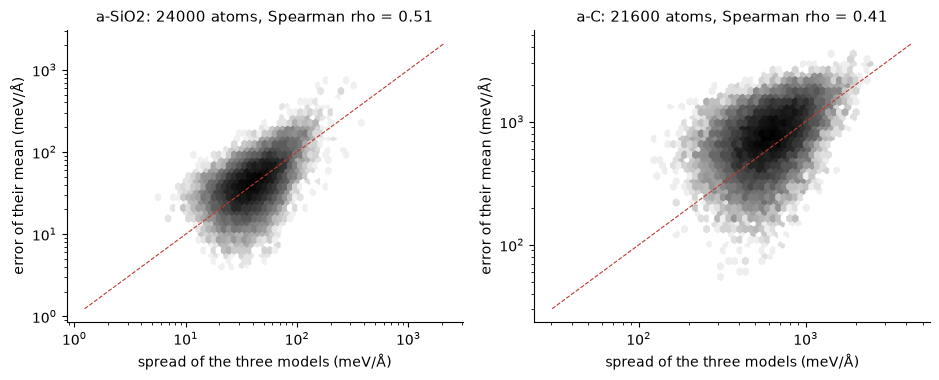

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.9))
for ax, system in zip(axes, ["a-SiO2", "a-C"]):
    sve = load(f"modules/M0_foundation_triage/outputs/spread_vs_error_{system}.csv")
    spread, error = 1e3 * sve["spread_eV_A"], 1e3 * sve["error_mean_model_eV_A"]
    ax.hexbin(spread, error, gridsize=45, bins="log", xscale="log", yscale="log", cmap="Greys")
    lim = [min(spread.min(), error.min()), max(spread.max(), error.max())]
    ax.plot(lim, lim, "--", color=FT, lw=0.8)
    ax.set_xlabel("spread of the three models (meV/Å)")
    ax.set_ylabel("error of their mean (meV/Å)")
    ax.set_title(f"{system}: {len(sve)} atoms, Spearman rho = {rho[system]:.2f}")
plt.tight_layout()
plt.show()

**What came out.** Silica is close already: 33 to 56 meV/Å force RMSE, 3 to 6 percent of the
spread of the reference forces. Carbon is not: 410 to 760 meV/Å. The energy error of the MIT
models on carbon is almost all a constant offset, −99 meV/atom for MPA-0 and −128 for MP-0b3.
Removing it leaves 13 and 16 meV/atom, against 10 for MH-1, whose offset is −6. The forces
carry no such offset, so the force error on carbon is real. The spread tracks the error
loosely: the dashed line is spread equal to error, and the Spearman coefficient is 0.51 on
silica and 0.41 on carbon (0.51 on Li–P–S, 0.21 on silicon, 0.22 on Ge–Sb–Te with the two MIT
models). The spread ranks atoms, which is what active learning needs. It is not an error bar.

MPA-0 is the base model for everything that follows. It is MIT, and on silica its zero-shot
error is 1.5 times MH-1's.

## 3. M1: fine-tuning MACE-MPA-0 on AM26 silica and carbon

**Question.** Transfer, not fit. Does a model fine-tuned on some AM26 cells work on cells it
never saw: other cells at the same conditions, a whole quench rate it never saw, a density band
it never saw? And does it hold up where the force RMSE cannot see, in dynamics?

**What was done.** Every run starts from MACE-MPA-0 and follows the recipe of Tompa and
co-workers: model-aware re-estimation of the atomic reference energies (`E0s: estimated`), the
Huber-type universal loss, zero weight decay, learning rate 5e-4, batch 2, 150 epochs, float64.
Nothing was tuned on a test set. The arms differ in what is held out:

| Arm | Train on | Test on |
|---|---|---|
| A naive, seeds 0, 1 and 2, plus a repeat | 51 random silica cells | 20 random silica cells |
| E learning curve | 10, 20 or 40 of those 51 | the same 20 |
| F noisy labels | the 51, a random tenth with Gaussian noise of 300 meV/Å on every force component and 50 meV/atom on the energy | the same 20 |
| B multihead replay | the 51 plus 1000 replayed pretraining structures, 30 epochs | the same 20 |
| rate14 | 60 cells at 10¹¹, 10¹² and 10¹³ K/s (51 train, 9 valid) | the 20 cells at 10¹⁴ K/s |
| rate11 | 60 cells at 10¹², 10¹³ and 10¹⁴ K/s (51 train, 9 valid) | the 20 cells at 10¹¹ K/s |
| D carbon | 64 carbon cells at 2.0 to 3.5 g/cm³ | the 25 most porous cells, 1.5 to 2.0 g/cm³ |

Every run writes `heldout_metrics.csv`, with the zero-shot base model evaluated on the same test
cells beside the fine-tuned one, and one line per test cell in `heldout_per_frame_*.csv`. The
interval on each error is a 95 percent bootstrap over the test cells, so a difference between
two runs can be read against the scatter of a 20-cell test set. `hpc/README.md` has the exact
submission of each arm and the M1 README the wall-clock per run.

In [7]:
RUNS = [  # folder under the M1 outputs, label, hold-out family, training cells
    ("",                              "naive, seed 0",                     "random split",   51),
    ("am26_asio2_mpa0_naive_s1",      "naive, seed 1",                     "random split",   51),
    ("am26_asio2_mpa0_naive_s2",      "naive, seed 2",                     "random split",   51),
    ("am26_asio2_mpa0_naive_holdmin", "naive, repeat of seed 0",           "random split",   51),
    ("am26_asio2_mpa0_naive_n40",     "40 training cells",                 "learning curve", 40),
    ("am26_asio2_mpa0_naive_n20",     "20 training cells",                 "learning curve", 20),
    ("am26_asio2_mpa0_naive_n10",     "10 training cells",                 "learning curve", 10),
    ("am26_asio2_mpa0_naive_noisy10", "a tenth of the labels corrupted",   "noisy labels",   51),
    ("am26_asio2_mpa0_replay_short",  "multihead replay, 30 epochs",       "replay",         51),
    ("am26_asio2_mpa0_naive_rate14",  "fastest rate held out, 10^14 K/s",  "rate hold-out",  51),
    ("am26_asio2_mpa0_naive_rate11",  "slowest rate held out, 10^11 K/s",  "rate hold-out",  51),
    ("am26_aC_mpa0_naive",            "carbon, porous quarter held out",   "carbon",         64),
]


def heldout(folder):
    "Zero-shot and fine-tuned held-out errors of one run, with bootstrap intervals over the test cells."
    d = ROOT / M1 / folder if folder else ROOT / M1
    m = pd.read_csv(d / "heldout_metrics.csv")
    zs, ft = m[m["model"] == "zero-shot"].iloc[0], m[m["model"] != "zero-shot"].iloc[0]
    out = {"n_test": int(ft["n_frames"])}
    for tag, row in (("zs", zs), ("ft", ft)):
        pf = pd.read_csv(d / f"heldout_per_frame_{row['model']}.csv")
        out[f"{tag}_F"], out[f"{tag}_lo"], out[f"{tag}_hi"] = bootstrap_rmse(pf["frame_force_rmse_meV_A"], pf["natoms"])
        out[f"{tag}_E"] = row["energy_mae_meV_atom"]
    return out


m1 = pd.DataFrame([{"run": label, "family": family, "n_train": n, **heldout(folder)}
                   for folder, label, family, n in RUNS]).set_index("run")
print("force RMSE per component in meV/Å with its 95 % interval; energy MAE in meV/atom")
m1[["family", "n_train", "n_test", "zs_F", "ft_F", "ft_lo", "ft_hi", "zs_E", "ft_E"]].rename(columns={
    "zs_F": "zero-shot F", "ft_F": "fine-tuned F", "ft_lo": "low", "ft_hi": "high", "zs_E": "zero-shot E", "ft_E": "fine-tuned E"})

force RMSE per component in meV/Å with its 95 % interval; energy MAE in meV/atom


,family,n_train,n_test,zero-shot F,fine-tuned F,low,high,zero-shot E,fine-tuned E
run,,,,,,,,,
"naive, seed 0",random split,51,20,49.921,15.268,12.437,18.169,0.392,0.453
"naive, seed 1",random split,51,20,49.921,15.167,12.394,18.011,0.392,0.465
"naive, seed 2",random split,51,20,49.921,15.263,12.456,18.129,0.392,0.475
"naive, repeat of seed 0",random split,51,20,49.921,15.365,12.482,18.310,0.392,0.446
40 training cells,learning curve,40,20,49.921,16.742,13.552,19.916,0.392,0.416
20 training cells,learning curve,20,20,49.921,26.195,17.988,33.894,0.392,0.752
10 training cells,learning curve,10,20,49.921,26.156,20.199,33.259,0.392,0.508
a tenth of the labels corrupted,noisy labels,51,20,49.921,16.440,13.422,19.482,0.392,1.120
"multihead replay, 30 epochs",replay,51,20,49.921,28.401,21.701,36.173,0.392,0.951


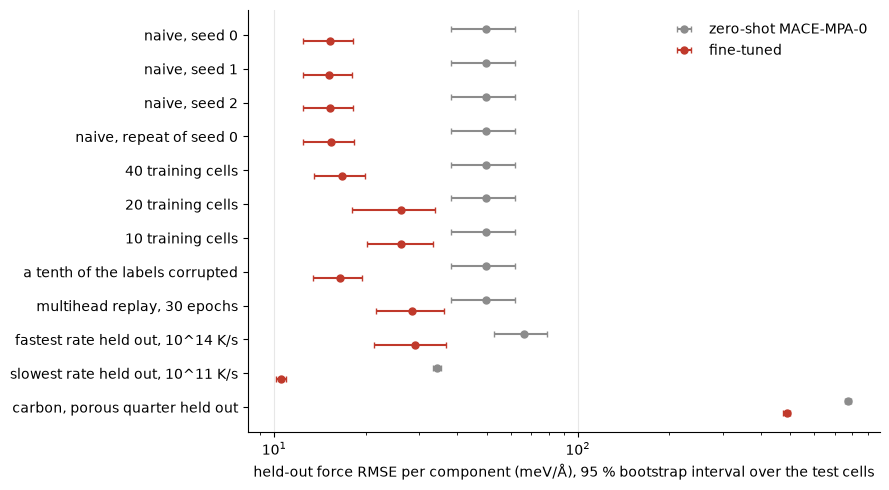

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(m1))[::-1]
for tag, dy, col, lab in (("zs", 0.17, ZS, "zero-shot MACE-MPA-0"), ("ft", -0.17, FT, "fine-tuned")):
    ax.errorbar(m1[f"{tag}_F"], y + dy, xerr=[m1[f"{tag}_F"] - m1[f"{tag}_lo"], m1[f"{tag}_hi"] - m1[f"{tag}_F"]],
                fmt="o", ms=5, color=col, capsize=2, label=lab)
ax.set_yticks(y)
ax.set_yticklabels(m1.index)
ax.set_xscale("log")
ax.set_xlabel("held-out force RMSE per component (meV/Å), 95 % bootstrap interval over the test cells")
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**What came out.**

- Fit on the random split: 50 to 15 meV/Å, and three seeds land within 0.1 of each other
  (15.2, 15.3, 15.3). The repeat gives 15.4.
- Learning curve: ten or twenty training cells give 26, forty give 17, all 51 give 15.
- Corrupted labels: 15.3 to 16.4 meV/Å on forces and 0.45 to 1.12 meV/atom on energies. The
  intervals overlap because they measure the scatter of one shared test set. The seed-to-seed
  spread of 0.1 meV/Å is the right yardstick, and the noise costs ten times that.
- Replay: 28 meV/Å after 30 epochs, against 15 for 150 naive epochs. Not comparable, and
  reported as a smoke test of the replay set-up; the 150-epoch replay run hit its 12 h walltime
  at epoch 32.
- Quench rate: fastest held out, 67 to 29; slowest held out, 34 to 10.5. The fast glasses are
  harder for every model. At 10¹⁴ K/s 0.75 percent of the silicons are not four-coordinated,
  at 10¹¹ K/s none are.
- Carbon: 777 to 486 meV/Å, a third off and still thirty times the silica error. Dense carbon
  does not teach porous carbon. The energy MAE drops from 91 to 13 meV/atom, mostly by
  removing M0's constant offset.

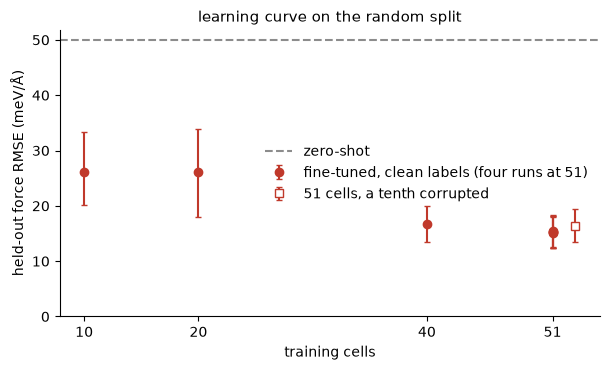

In [9]:
lc = m1[m1["family"].isin(["random split", "learning curve"])]
noisy = m1.loc["a tenth of the labels corrupted"]
fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.errorbar(lc["n_train"], lc["ft_F"], yerr=[lc["ft_F"] - lc["ft_lo"], lc["ft_hi"] - lc["ft_F"]],
            fmt="o", color=FT, capsize=2, label="fine-tuned, clean labels (four runs at 51)")
ax.errorbar([noisy["n_train"] + 2], [noisy["ft_F"]], yerr=[[noisy["ft_F"] - noisy["ft_lo"]], [noisy["ft_hi"] - noisy["ft_F"]]],
            fmt="s", mfc="white", color=FT, capsize=2, label="51 cells, a tenth corrupted")
ax.axhline(m1.loc["naive, seed 0", "zs_F"], ls="--", color=ZS, label="zero-shot")
ax.set_xlabel("training cells")
ax.set_ylabel("held-out force RMSE (meV/Å)")
ax.set_ylim(0, None)
ax.set_xticks([10, 20, 40, 51])
ax.set_title("learning curve on the random split")
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

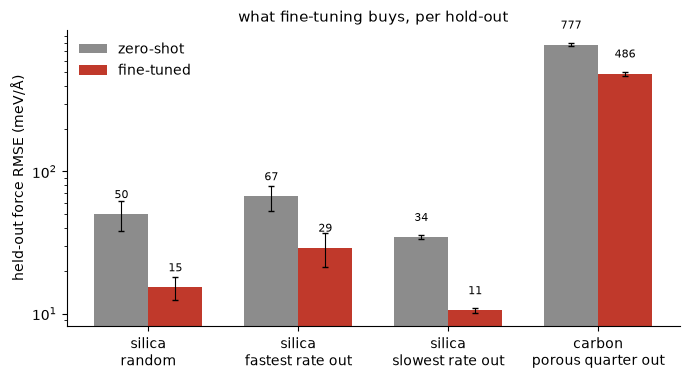

In [10]:
transfer = m1.loc[["naive, seed 0", "fastest rate held out, 10^14 K/s", "slowest rate held out, 10^11 K/s",
                   "carbon, porous quarter held out"]]
names = ["silica\nrandom", "silica\nfastest rate out", "silica\nslowest rate out", "carbon\nporous quarter out"]
fig, ax = plt.subplots(figsize=(7, 3.9))
x, w = np.arange(len(transfer)), 0.36
for dx, tag, col, lab in ((-w / 2, "zs", ZS, "zero-shot"), (w / 2, "ft", FT, "fine-tuned")):
    ax.bar(x + dx, transfer[f"{tag}_F"], w, color=col, label=lab, capsize=2, error_kw={"lw": 0.8},
           yerr=[transfer[f"{tag}_F"] - transfer[f"{tag}_lo"], transfer[f"{tag}_hi"] - transfer[f"{tag}_F"]])
    for xi, v in zip(x + dx, transfer[f"{tag}_F"]):
        ax.text(xi, v * 1.3, f"{v:.0f}", ha="center", fontsize=8)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("held-out force RMSE (meV/Å)")
ax.set_title("what fine-tuning buys, per hold-out")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [11]:
rows = []
for folder, label in (("", "naive, seed 0"), ("am26_asio2_mpa0_naive_rate14", "fastest rate held out, 10^14 K/s"),
                      ("am26_asio2_mpa0_naive_rate11", "slowest rate held out, 10^11 K/s")):
    m = pd.read_csv(ROOT / M1 / folder / "heldout_metrics.csv") if folder else pd.read_csv(ROOT / M1 / "heldout_metrics.csv")
    for _, r in m.iterrows():
        rows.append({"run": label, "model": "zero-shot" if r["model"] == "zero-shot" else "fine-tuned",
                     "Si": r["force_rmse_Si_meV_A"], "O": r["force_rmse_O_meV_A"]})
print("force RMSE per element on the held-out silica cells, meV/Å")
pd.DataFrame(rows).set_index(["run", "model"])

force RMSE per element on the held-out silica cells, meV/Å


Si       O
run                              model                     
naive, seed 0                    zero-shot   65.913  39.571
                                 fine-tuned  20.329  11.961
fastest rate held out, 10^14 K/s zero-shot   88.191  52.684
                                 fine-tuned  40.002  21.463
slowest rate held out, 10^11 K/s zero-shot   44.545  28.051
                                 fine-tuned  13.679   8.538

Silicon carries the larger error in every run, before and after fine-tuning: 20 against 12
meV/Å on the random split, 40 against 21 with the fastest rate held out.

### The MD check

The force RMSE is blind to what happens in dynamics, so `md_stability.py` runs 20 ps of
Langevin NVT at 300 K and at 1500 K on the first held-out silica cell, zero-shot and
fine-tuned, in float64. It records the potential-energy drift over the second half, the
shortest interatomic distance at the start and the end, and the coordination fractions. A fit
that collapsed at 1500 K would fail here whatever its RMSE.

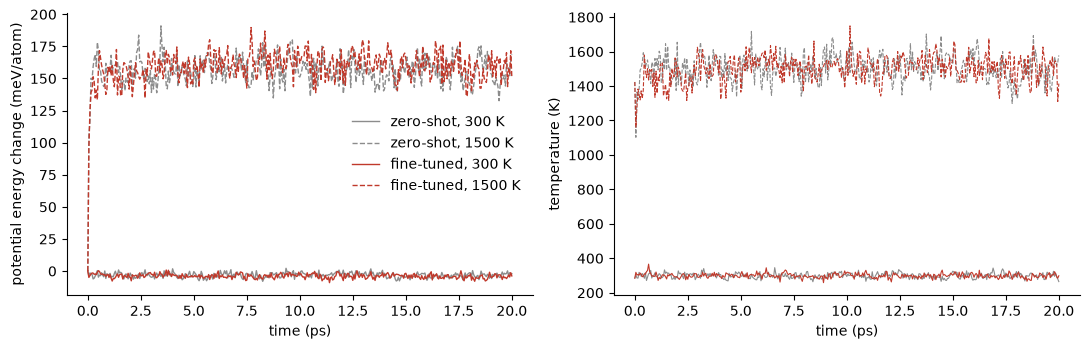

,model,T_K,ps_completed,finished,epot_drift_second_half_meV_atom_per_ps,dmin_start_A,dmin_end_A,frac_Si_CN4_end,frac_O_CN2_end,ms_per_step
0,zero-shot,300.0,20.0,True,-0.111,1.535,1.533,1.0,1.0,224.400
1,zero-shot,1500.0,20.0,True,-0.046,1.535,1.444,1.0,1.0,224.550
2,naive,300.0,20.0,True,-0.081,1.535,1.544,1.0,1.0,119.165
3,naive,1500.0,20.0,True,-0.595,1.535,1.484,1.0,1.0,119.476


In [12]:
mdsum = load(f"{M1}/md_stability/md_stability_summary.csv")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for model, col in (("zero-shot", ZS), ("naive", FT)):
    for T, ls in ((300, "-"), (1500, "--")):
        s = load(f"{M1}/md_stability/series_{model}_{T}K.csv")
        axes[0].plot(s["t_ps"], 1e3 * (s["epot_eV_atom"] - s["epot_eV_atom"].iloc[0]), ls, color=col, lw=1,
                     label=f"{'fine-tuned' if model == 'naive' else model}, {T} K")
        axes[1].plot(s["t_ps"], s["T_K"], ls, color=col, lw=0.8)
axes[0].set_xlabel("time (ps)")
axes[0].set_ylabel("potential energy change (meV/atom)")
axes[0].legend()
axes[1].set_xlabel("time (ps)")
axes[1].set_ylabel("temperature (K)")
plt.tight_layout()
plt.show()
mdsum[["model", "T_K", "ps_completed", "finished", "epot_drift_second_half_meV_atom_per_ps", "dmin_start_A", "dmin_end_A",
       "frac_Si_CN4_end", "frac_O_CN2_end", "ms_per_step"]]

Both models hold the cell for the full 20 ps at both temperatures. Every silicon is
four-coordinated at the end, the shortest interatomic distance stays between 1.44 and 1.54 Å,
and the drift over the second half is at most 0.6 meV/atom per ps. The fine-tuned model was
also run in float32 (`md_stability_am26_asio2_mpa0_naive/`), at 31 ms per step against 119 in
float64, with the same outcome.

### The melt-quench

The sharper test: can the fine-tuned model make a glass of its own, from a liquid it never saw
in training, and does that glass look like AM26's at the same cooling rate? `melt_quench.py`
starts from an AM26 10¹⁴ K/s cell, holds it at 5000 K for 20 ps in NVT at that cell's density,
cools it at 100 K/ps, which is 10¹⁴ K/s, to 300 K, holds 5 ps there, and compares the final
cell with AM26's twenty 10¹⁴ K/s cells. Five runs, each from a different cell; the fifth, seed
4 in the table, saved a frame every 250 steps for the figures and the video.

**The check that matters.** My first attempt, 10 ps at 3000 K, did not melt anything, and I
first read it the wrong way round. Compared with their true parents, 93 to 100 percent of the
Si–O–Si bridges survived, and the mean squared displacement of silicon sat on a plateau at
0.66 Å² against (V/N)^(2/3) = 6.1 Å². Those cells were AM26 cells heated and cooled, not glasses
the model made. The script now records, for every run, the mean squared displacement at the
end of the hold, the fraction of bridges kept and a `network_reset` flag, and the table below is
that record for the 5000 K runs. The 3000 K bridge counts came from a cross-check with ZIPPER
that is not in this repository; the 3000 K outputs in `melt_quench_naive/` predate the
diagnostic.

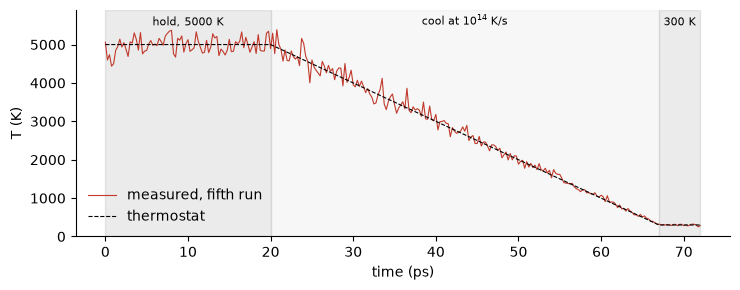

,seed,start_label,finished,steps_done,ms_per_step,msd_Si_end_hold_A2,ell2_A2,bridges_kept_end_hold,network_reset,dmin_end_A,frac_Si_CN4_end,frac_O_CN2_end
0,0,silica-mq_10-14_1,True,72000,45.762,89.013,6.071,0.025,True,1.553,0.97,0.995
1,1,silica-mq_10-14_10,True,72000,46.997,85.337,6.112,0.041,True,1.525,1.00,0.990
2,2,silica-mq_10-14_11,True,72000,56.165,92.058,6.130,0.045,True,1.551,1.00,1.000
3,3,silica-mq_10-14_12,True,72000,45.328,102.875,6.083,0.040,True,1.541,1.00,0.990
4,4,silica-mq_10-14_13,True,72000,46.050,93.035,6.026,0.025,True,1.553,1.00,1.000


In [13]:
mq = f"{M1}/melt_quench_5000K"
s4 = load(f"{mq}/series_naive_seed4.csv")
fig, ax = plt.subplots(figsize=(7.5, 3))
ax.plot(s4["t_ps"], s4["T_K"], color=FT, lw=0.8, label="measured, fifth run")
ax.plot(s4["t_ps"], s4["T_set_K"], "k--", lw=0.8, label="thermostat")
for t0, t1, lab, alpha in ((0, 20, "hold, 5000 K", 0.08), (20, 67, "cool at 10$^{14}$ K/s", 0.03), (67, 72, "300 K", 0.08)):
    ax.axvspan(t0, t1, color="k", alpha=alpha)
    ax.text((t0 + t1) / 2, 5500, lab, ha="center", fontsize=8)
ax.set_xlabel("time (ps)")
ax.set_ylabel("T (K)")
ax.set_ylim(0, 5900)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

runs = load(f"{mq}/melt_quench_summary.csv")
runs[["seed", "start_label", "finished", "steps_done", "ms_per_step", "msd_Si_end_hold_A2", "ell2_A2",
      "bridges_kept_end_hold", "network_reset", "dmin_end_A", "frac_Si_CN4_end", "frac_O_CN2_end"]]

At the end of the hold silicon had moved 85 to 103 Å², fourteen to seventeen times (V/N)^(2/3), and 2.5 to
4.5 percent of the starting bridges were left, which is the level two unrelated AM26 cells
share by coincidence (1.5 to 5.5 percent). The network was gone. Every run finished its 72 000
steps at 45 to 56 ms per step, and the shortest distance at the end is 1.53 to 1.55 Å, although
AM26's silica set contains no liquid configurations at all.

In [14]:
vs = load(f"{mq}/melt_quench_vs_am26.csv")
vs["fine-tuned model, 5 cells"] = [f"{m:.3f} ± {s:.3f}" for m, s in zip(vs["generated_mean"], vs["generated_sd"])]
vs["AM26 at 10^14 K/s, 20 cells"] = [f"{m:.3f} ± {s:.3f}" for m, s in zip(vs["am26_mean"], vs["am26_sd"])]
print("mean ± standard deviation across cells; ring length in atoms from matscipy; density is fixed by the starting cell")
vs[["descriptor", "fine-tuned model, 5 cells", "AM26 at 10^14 K/s, 20 cells"]].set_index("descriptor")

mean ± standard deviation across cells; ring length in atoms from matscipy; density is fixed by the starting cell


,"fine-tuned model, 5 cells","AM26 at 10^14 K/s, 20 cells"
descriptor,,
density,2.216 ± 0.022,2.230 ± 0.026
frac_O_CN2,0.995 ± 0.005,0.997 ± 0.003
frac_Si_CN4,0.994 ± 0.013,0.993 ± 0.007
ring_mean_length_atoms,10.998 ± 0.377,10.978 ± 0.237


Coordination and the ring length agree within the scatter. The ZIPPER cross-check
(`modules/story/rings_zipper_crosscheck.md`), which counts rings in silicons, gives 6.74 ± 0.12
against 6.60 ± 0.16, three-rings 5.1 against 5.2 percent, and nine- to twelve-rings 23 against
18 percent, a possible excess of large rings that five cells cannot settle. The partial RDFs
below were computed with CRISP by `tools/story_plots.py` and saved to `modules/story/fig_A_prdf.csv`.

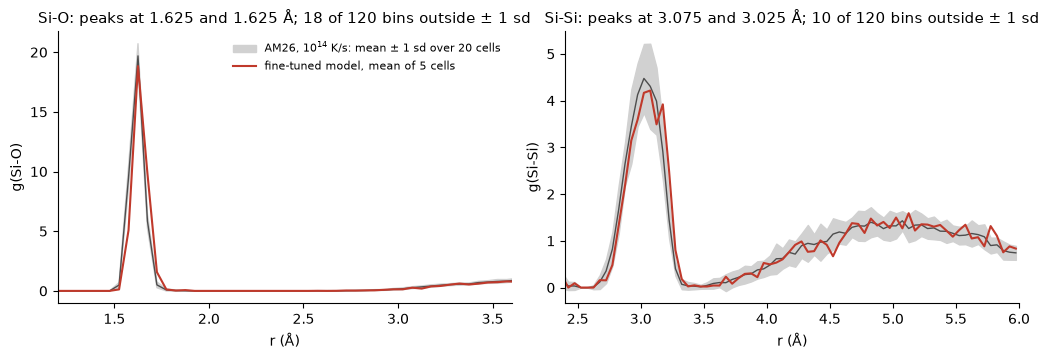

In [15]:
prdf = load("modules/story/fig_A_prdf.csv")
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.7))
for ax, (pair, g) in zip(axes, prdf.groupby("pair", sort=False)):
    ax.fill_between(g["r_A"], g["am26_mean"] - g["am26_sd"], g["am26_mean"] + g["am26_sd"], color="0.82",
                    label="AM26, 10$^{14}$ K/s: mean ± 1 sd over 20 cells")
    ax.plot(g["r_A"], g["am26_mean"], color="0.3", lw=1)
    ax.plot(g["r_A"], g["generated_mean"], color=FT, lw=1.5, label="fine-tuned model, mean of 5 cells")
    peak_gen = g["r_A"].to_numpy()[g["generated_mean"].to_numpy().argmax()]
    peak_am26 = g["r_A"].to_numpy()[g["am26_mean"].to_numpy().argmax()]
    outside = int(((g["generated_mean"] - g["am26_mean"]).abs() > g["am26_sd"]).sum())
    ax.set_title(f"{pair}: peaks at {peak_gen:.3f} and {peak_am26:.3f} Å; {outside} of {len(g)} bins outside ± 1 sd")
    ax.set_xlabel("r (Å)")
    ax.set_ylabel(f"g({pair})")
    ax.set_xlim((1.2, 3.6) if pair == "Si-O" else (2.4, 6.0))
axes[0].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

The Si–O peaks coincide at 1.625 Å. The Si–Si peak of the model's glass is one 0.05 Å bin
further out, 3.075 against 3.025 Å, and 18 of the 120 Si–O bins and 10 of the 120 Si–Si bins
lie more than one AM26 standard deviation from the AM26 mean. Within what five cells can say,
the glass is consistent with AM26 at this cooling rate. It is not "inside the band".

in the hold, 1 to 20 ps: 42 % of the silicons have three oxygens within 2.0 Å and 49 % have four, averaged over frames
at least 99 % four-coordinated from 51 ps on, thermostat at 1900 K


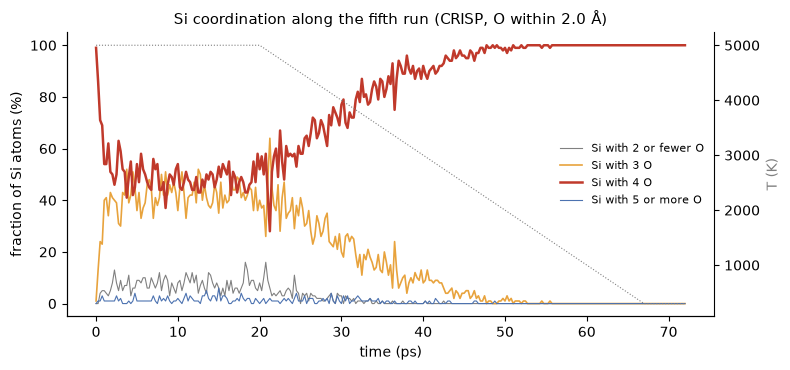

In [16]:
cn = load("modules/story/coordination_along_quench.csv")
hold = cn[(cn["t_ps"] >= 1) & (cn["t_ps"] <= 20)]
ok = (cn["Si_CN4_percent"] >= 99).to_numpy()
i_back = next(i for i in range(len(ok)) if ok[i:].all())
print(f"in the hold, 1 to 20 ps: {hold['Si_CN3_percent'].mean():.0f} % of the silicons have three oxygens within 2.0 Å "
      f"and {hold['Si_CN4_percent'].mean():.0f} % have four, averaged over frames")
print(f"at least 99 % four-coordinated from {cn['t_ps'].iloc[i_back]:.0f} ps on, thermostat at {cn['T_set_K'].iloc[i_back]:.0f} K")

groups = {"2 or fewer O": cn[["Si_CN0_percent", "Si_CN1_percent", "Si_CN2_percent"]].sum(axis=1), "3 O": cn["Si_CN3_percent"],
          "4 O": cn["Si_CN4_percent"], "5 or more O": cn[["Si_CN5_percent", "Si_CN6_percent"]].sum(axis=1)}
fig, ax = plt.subplots(figsize=(8, 3.8))
for (lab, y), col, lw in zip(groups.items(), ("0.5", "#e8a33d", FT, "#4c72b0"), (0.8, 1.2, 1.8, 0.8)):
    ax.plot(cn["t_ps"], y, color=col, lw=lw, label=f"Si with {lab}")
ax2 = ax.twinx()
ax2.plot(cn["t_ps"], cn["T_set_K"], ":", color="0.5", lw=0.8)
ax2.set_ylabel("T (K)", color="0.5")
ax2.spines["right"].set_visible(True)
ax.set_xlabel("time (ps)")
ax.set_ylabel("fraction of Si atoms (%)")
ax.set_title("Si coordination along the fifth run (CRISP, O within 2.0 Å)")
ax.legend(loc="center right", fontsize=8)
plt.tight_layout()
plt.show()

In the liquid about 42 percent of the silicons have exactly three oxygens within 2.0 Å at any
instant, and the four-coordinated fraction is back above 99 percent from 51 ps on, when the
thermostat is at 1900 K. The three-coordinated fraction depends on the 2.0 Å cutoff, which is
too tight for a liquid this hot, and it comes from a region the model never saw in training. It
says what the model does there, not what liquid silica does.

### The seed committee

Three seeds of the naive fine-tune were evaluated on the saved frames of every run, the
committee check of Schran, Brezina and Marsalek; Beck and co-workers build the same idea into
one foundation model with several heads. The spread is the norm of the per-atom standard
deviation of the force over the seeds, so it is compared with the per-atom error on the held-out
glass, √3 times the per-component RMSE.

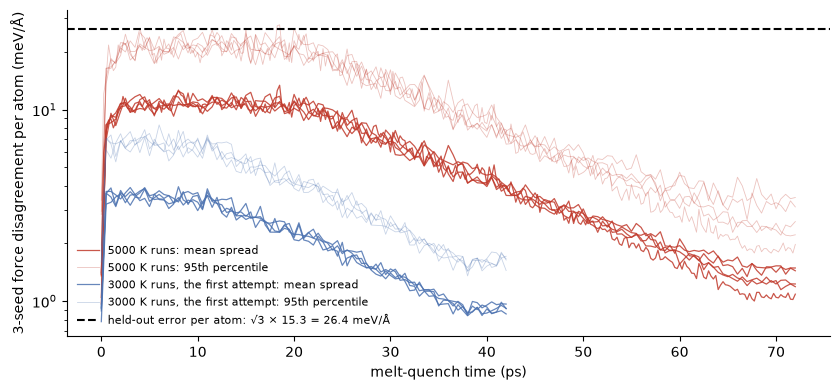

5000 K liquid: mean spread 10.3 meV/Å, 95th percentile 20.6
3000 K hold: mean spread 3.4 meV/Å, 95th percentile 6.4
final glass of the 5000 K runs: mean spread 1.3 meV/Å
final glass of the 3000 K runs: mean spread 0.9 meV/Å


In [17]:
def committee(folder):
    return [pd.read_csv(f) for f in sorted((ROOT / M1 / folder).glob("committee_along_quench_seed*.csv"))]


hot, warm = committee("melt_quench_5000K"), committee("melt_quench_naive")
per_component = m1.loc["naive, seed 0", "ft_F"]
per_atom = np.sqrt(3) * per_component

fig, ax = plt.subplots(figsize=(8.5, 4))
for series, col, lab in ((hot, FT, "5000 K runs"), (warm, "#4c72b0", "3000 K runs, the first attempt")):
    for k, c in enumerate(series):
        ax.plot(c["t_ps"], 1e3 * c["spread_mean_eV_A"], color=col, lw=0.9, alpha=0.85, label=f"{lab}: mean spread" if k == 0 else None)
        ax.plot(c["t_ps"], 1e3 * c["spread_p95_eV_A"], color=col, lw=0.6, alpha=0.3, label=f"{lab}: 95th percentile" if k == 0 else None)
ax.axhline(per_atom, ls="--", color="k", label=f"held-out error per atom: √3 × {per_component:.1f} = {per_atom:.1f} meV/Å")
ax.set_yscale("log")
ax.set_xlabel("melt-quench time (ps)")
ax.set_ylabel("3-seed force disagreement per atom (meV/Å)")
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

all_hot, all_warm = pd.concat(hot), pd.concat(warm)
for name, d, T in (("5000 K liquid", all_hot, 5000), ("3000 K hold", all_warm, 3000)):
    sel = d[d["T_set_K"] == T]
    print(f"{name}: mean spread {1e3 * sel['spread_mean_eV_A'].mean():.1f} meV/Å, 95th percentile {1e3 * sel['spread_p95_eV_A'].mean():.1f}")
for name, d in (("final glass of the 5000 K runs", all_hot), ("final glass of the 3000 K runs", all_warm)):
    sel = d[d["T_set_K"] <= 300]
    print(f"{name}: mean spread {1e3 * sel['spread_mean_eV_A'].mean():.1f} meV/Å")

In the 5000 K liquid the spread averages 10 meV/Å with a 95th percentile of 21. In the final
glass it is 1.3 meV/Å, twenty times below the per-atom error of 26. At 3000 K it was 3.4. The
spread rises eightfold where the model extrapolates, which is the useful part. As an error bar
it is too small everywhere: seeds of one fine-tuned foundation model share their training data
and their base, so they agree with each other more than with DFT.

Three snapshots of the fifth run, liquid, mid-quench and glass, with CRISP's partial RDFs
against the AM26 average, and one frame of `modules/story/quench_video.mp4`: every silicon
coloured by its oxygen count within 2.0 Å (dark grey two or fewer, orange three, red four, blue
five or more) next to the RDFs of that frame and the coordination curve so far. Both were made
by `tools/story_dynamic.py` and `tools/story_video.py` from the saved trajectory, which is not
committed.

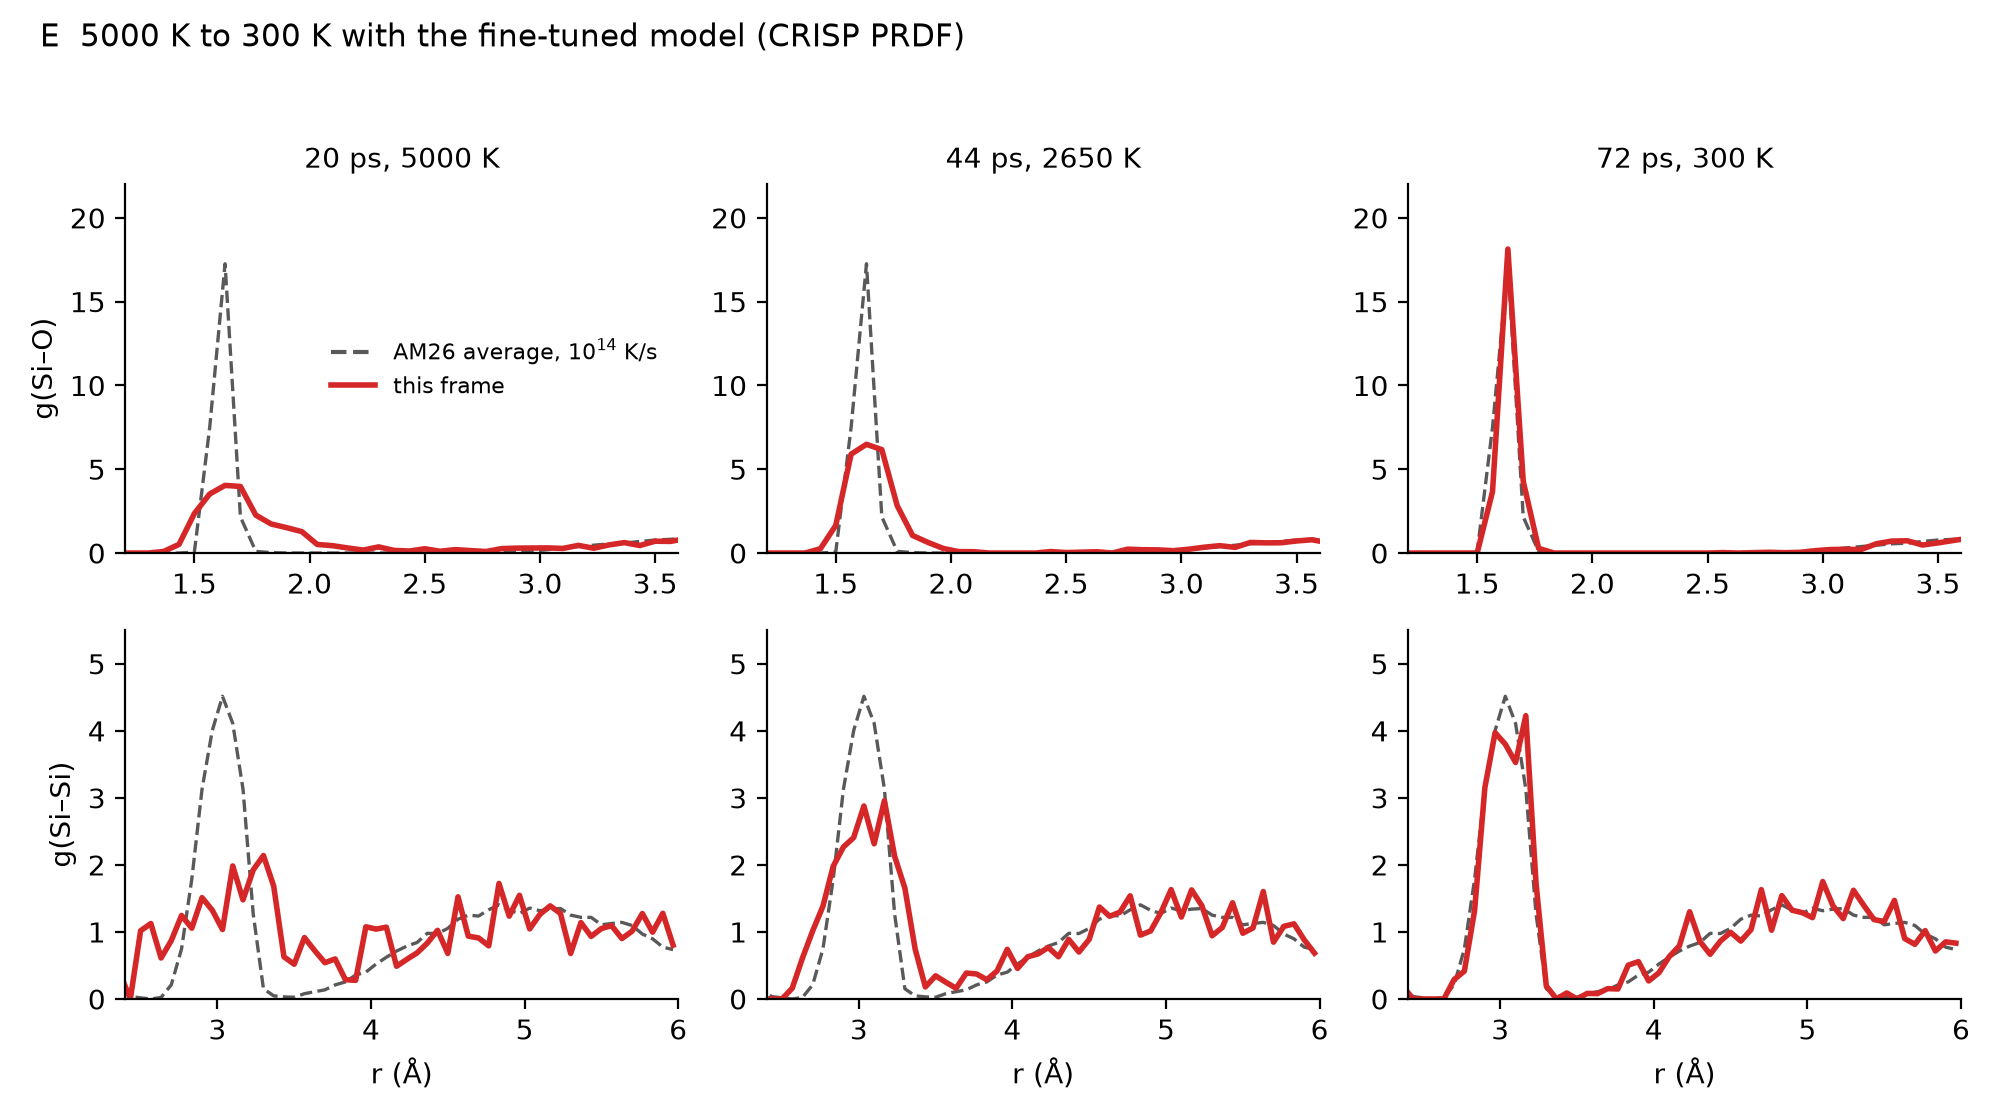

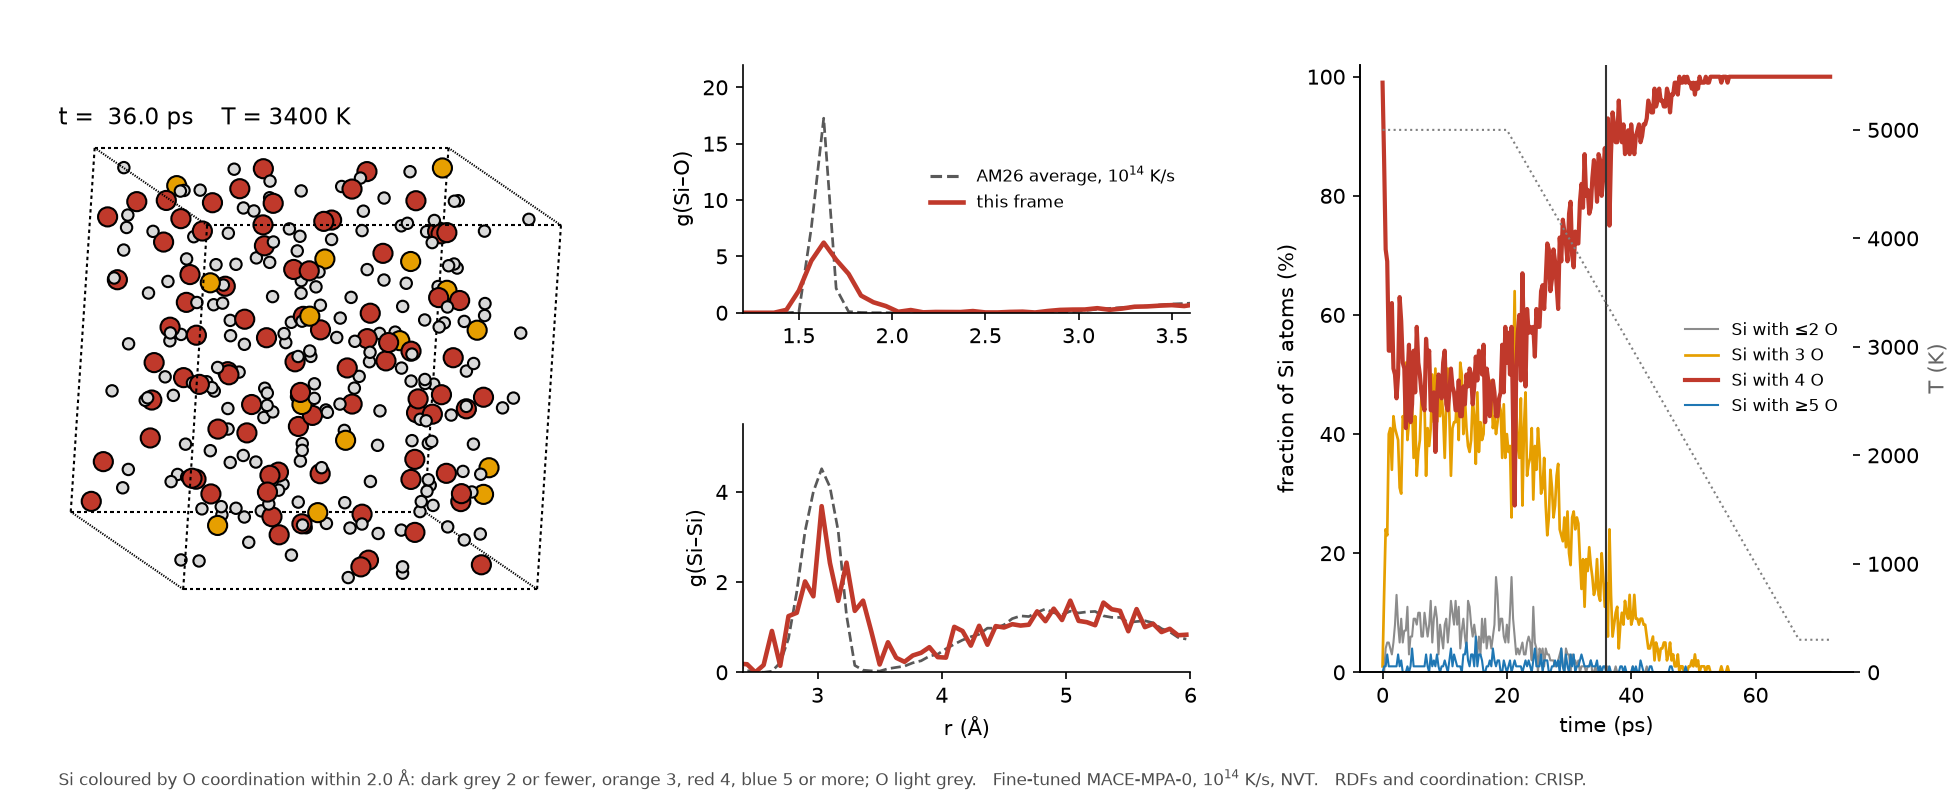

In [18]:
display(Image(filename=str(ROOT / "modules/story/fig_E_quench_snapshots.png"), width=900))
display(Image(filename=str(ROOT / "modules/story/quench_video_frame_1.png"), width=900))

## 4. M2: how many amorphous cells are enough?

**Question.** In an amorphous host there is no unit cell to average over. Pore size,
coordination and ring statistics are distributions over an ensemble of cells, and the width of
that ensemble is part of the physics. How many independent cells does it take before each
observable is pinned down to a tolerance I am willing to declare, and how far is AM26, with
twenty cells per quench rate, from that point?

**What was done.** The criterion is Vitriflow's (Cottom, Delhomme and Olsson, 2026). For a
descriptor y measured on n cells, R_y(n) = h_n(y) / τ_y, with h_n the 95 percent confidence
half-width across cells and τ_y a declared resolution; a population is supported when
Q(n) = max_y R_y(n) ≤ 0.2. The tolerances follow their silica settings: density to 1 percent,
pair-distance and coordination CDFs to 2 percentage points, the ring-size PMF to 5 points.
`modules/M2_ensemble_support/run.py` computes the descriptors of every AM26 cell with ASE and
matscipy, draws random subsets of n cells, and writes the median R and its quartiles for every
n. For their own SHIK silica population, Vitriflow needed 560 cells for density and 420 for the
Si–Si pair-distance CDF. This is a convergence criterion applied to someone else's structures,
not a Vitriflow run.

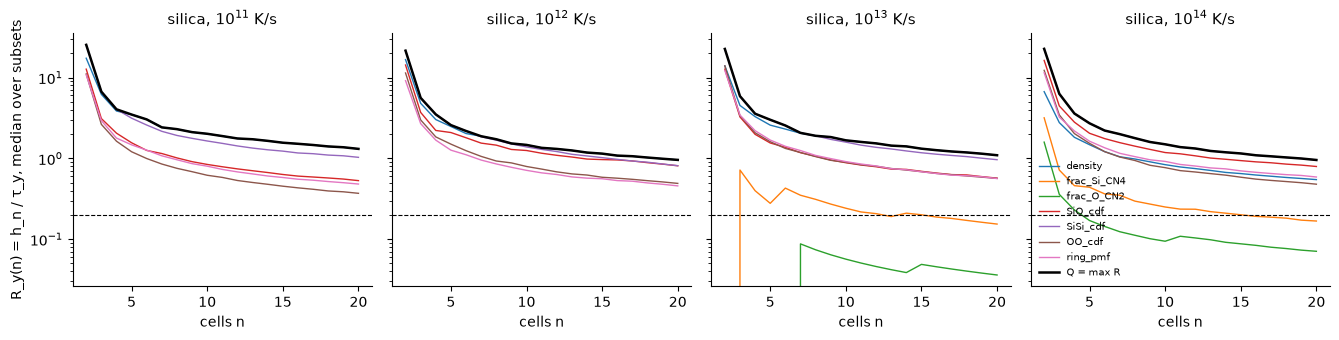

In [19]:
sup = load("modules/M2_ensemble_support/outputs/support_summary.csv")
curve_files = sorted(f for f in (ROOT / "modules/M2_ensemble_support/outputs").glob("support_curve_a-SiO2_*.csv")
                     if not f.name.endswith("_all.csv"))
fig, axes = plt.subplots(1, 4, figsize=(13.5, 3.5), sharey=True)
for ax, f in zip(axes, curve_files):
    c = pd.read_csv(f)
    for d, g in c.groupby("descriptor", sort=False):
        if d != "Q":
            ax.plot(g["n"], g["R_median"], lw=1, label=d)
    q = c[c["descriptor"] == "Q"]
    ax.plot(q["n"], q["R_median"], "k", lw=1.8, label="Q = max R")
    ax.axhline(0.2, ls="--", color="k", lw=0.8)
    ax.set_yscale("log")
    ax.set_xlabel("cells n")
    ax.set_title(f"silica, 10$^{{{int(c['group'].iloc[0])}}}$ K/s")
axes[0].set_ylabel("R_y(n) = h_n / τ_y, median over subsets")
axes[-1].legend(fontsize=7, loc="lower left")
plt.tight_layout()
plt.show()

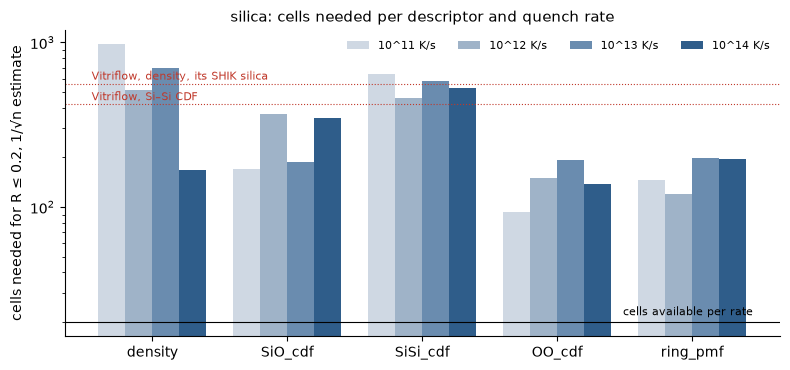

R at the 20 cells available, per descriptor and quench rate (silica); 0.2 is the target


group,11.0,12.0,13.0,14.0
descriptor,,,,
OO_cdf,0.37,0.49,0.57,0.48
Q,1.31,0.96,1.09,0.95
SiO_cdf,0.53,0.81,0.57,0.79
SiSi_cdf,1.03,0.81,0.96,0.95
density,1.31,0.96,1.09,0.55
frac_O_CN2,0.00,0.00,0.04,0.07
frac_Si_CN4,0.00,0.00,0.15,0.17
ring_pmf,0.48,0.46,0.56,0.59


In [20]:
unresolved = ["density", "SiO_cdf", "SiSi_cdf", "OO_cdf", "ring_pmf"]
silica = sup[sup["system"] == "a-SiO2"]
need = silica.pivot(index="descriptor", columns="group", values="n_extrapolated_sqrt").loc[unresolved]
need.columns = [f"10^{int(g)} K/s" for g in need.columns]

fig, ax = plt.subplots(figsize=(8, 3.8))
need.plot.bar(ax=ax, width=0.8, color=["#cfd8e3", "#9fb3c8", "#6a8caf", "#2f5d8a"])
ax.axhline(20, color="k", lw=0.8)
ax.text(4.45, 22, "cells available per rate", ha="right", fontsize=8)
for y, lab in ((560, "Vitriflow, density, its SHIK silica"), (420, "Vitriflow, Si–Si CDF")):
    ax.axhline(y, ls=":", color=FT, lw=0.8)
    ax.text(-0.45, y * 1.06, lab, fontsize=8, color=FT)
ax.set_yscale("log")
ax.set_ylabel("cells needed for R ≤ 0.2, 1/√n estimate")
ax.set_xlabel("")
ax.set_title("silica: cells needed per descriptor and quench rate")
ax.legend(fontsize=8, ncol=4, loc="upper right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("R at the 20 cells available, per descriptor and quench rate (silica); 0.2 is the target")
silica.pivot(index="descriptor", columns="group", values="R_at_N").round(2)

**What came out.** Twenty cells per rate are far from enough for any distribution-valued
descriptor. At every rate the Si–Si pair-distance CDF sits at R = 0.8 to 1.0, four to five
times the target, and the 1/√n estimate puts the number of cells needed at roughly 450 to 650,
the same order as Vitriflow's 420. The silica density would need 170 to 980 cells. Coordination
is the exception. At 10¹¹ and 10¹² K/s every silicon in every cell is four-coordinated, the
width across cells is zero and R = 0 from two cells on. At 10¹³ and 10¹⁴ K/s, where defects
appear, the Si coordination fraction needs 16 cells. The carbon groups, in the same table,
behave alike, with density at R = 0 by construction, since density is the grouping variable
there. The extrapolation assumes R falls as 1/√n, and the subsets are drawn from the same
twenty cells, so these are estimates of scale, not predictions.

## 5. M4: how clean are the reference forces?

**Question.** For a periodic DFT cell the forces must sum to zero. Whatever remains is
numerical noise in the labels, and no model trained on them can be checked below that level.
Kuryla, Berger, Csányi and Michaelides used this check to show that several widely used
molecular datasets carry much larger force uncertainties than assumed. What does it say about
AM26?

**What was done.** `modules/M4_label_quality/run.py` computes |ΣF| and |ΣF|/N for every cell
of every system. It takes seconds on one core. The expected column of the table is what
rounding alone produces for a cell of N atoms: AM26 stores forces with eight decimals in eV/Å,
so every component carries a uniform rounding error with standard deviation 10⁻⁸/√12, and the
net force of N such atoms is a three-dimensional Gaussian with that standard deviation times
√N. The ratio column divides the observed value by it, cell by cell.

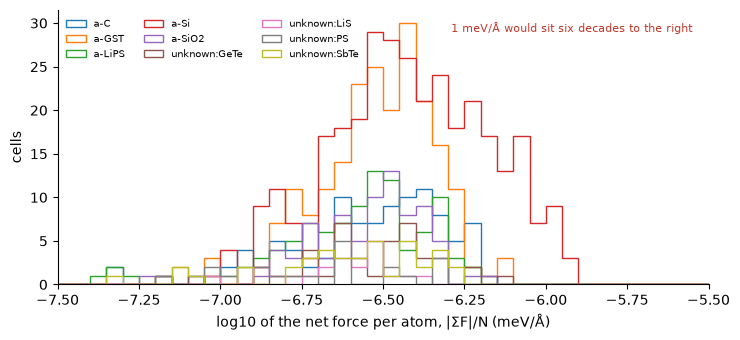

medians over cells; 'expected' is what rounding to eight decimals alone gives a cell of N atoms, and the ratio is taken cell by cell


,n_frames,median_meV_A,p95_meV_A,max_meV_A,expected_from_rounding_meV_A,observed_over_expected,fraction_above_1_meV_A
system,,,,,,,
a-C,100,3.241e-07,5.968e-07,6.365e-07,3.021e-07,1.073,0.0
a-GST,210,3.142e-07,5.213e-07,7.566e-07,3.156e-07,1.086,0.0
a-LiPS,100,2.816e-07,4.938e-07,5.900e-07,2.514e-07,1.088,0.0
a-Si,324,3.827e-07,9.111e-07,1.220e-06,5.550e-07,0.981,0.0
a-SiO2,80,3.145e-07,4.552e-07,6.481e-07,2.564e-07,1.227,0.0
unknown:GeTe,40,3.317e-07,5.743e-07,7.479e-07,3.021e-07,1.136,0.0
unknown:LiS,20,2.563e-07,3.760e-07,4.343e-07,2.467e-07,1.039,0.0
unknown:PS,20,2.298e-07,4.674e-07,4.931e-07,2.967e-07,0.775,0.0
unknown:SbTe,40,2.606e-07,4.925e-07,5.386e-07,3.310e-07,0.844,0.0


In [21]:
from scipy import stats

nf = load("modules/M4_label_quality/outputs/net_force_per_frame.csv")
summary = load("modules/M4_label_quality/outputs/net_force_summary.csv").set_index("system")
sigma = 1e-8 / np.sqrt(12)  # eV/Å per component, from rounding to eight decimals
nf["expected_from_rounding_meV_A"] = 1e3 * stats.chi.median(3) * sigma / np.sqrt(nf["natoms"])  # per cell, with its own N
nf["observed_over_expected"] = nf["net_force_per_atom_meV_A"] / nf["expected_from_rounding_meV_A"]
summary = summary.join(nf.groupby("system")[["expected_from_rounding_meV_A", "observed_over_expected"]].median())

fig, ax = plt.subplots(figsize=(7.5, 3.5))
edges = np.linspace(-7.5, -5.5, 41)
for system, g in nf.groupby("system"):
    ax.hist(np.log10(g["net_force_per_atom_meV_A"]), bins=edges, histtype="step", label=system)
ax.text(-5.55, ax.get_ylim()[1] * 0.92, "1 meV/Å would sit six decades to the right", color=FT, fontsize=8, ha="right")
ax.set_xlim(-7.5, -5.5)
ax.set_xlabel("log10 of the net force per atom, |ΣF|/N (meV/Å)")
ax.set_ylabel("cells")
ax.legend(fontsize=7, ncol=3, loc="upper left")
plt.tight_layout()
plt.show()
print("medians over cells; 'expected' is what rounding to eight decimals alone gives a cell of N atoms, and the ratio is taken cell by cell")
summary[["n_frames", "median_meV_A", "p95_meV_A", "max_meV_A", "expected_from_rounding_meV_A", "observed_over_expected", "fraction_above_1_meV_A"]]

**What came out.** The net force per atom has a median of about 3 × 10⁻⁷ meV/Å in every
system, within a factor of 1.3 of what rounding the stored forces to eight decimals produces on
its own. That is consistent with forces that were drift-corrected before they were written, and
it means this test cannot see AM26's SCF noise. On raw DFT output the same check measures the
noise floor against which the M0 and M1 errors should be read. Here it shows only that the net
force was removed. The module stays because it costs seconds and is the first thing to run on
any new reference set.

## 6. What this does not show, and what comes next

Agreement with experiment: the labels and the MIT models share the PBE level, so M0 and M1
measure consistency with PBE. Two materials, three silica hold-outs and one carbon hold-out.
M2 is a criterion applied to someone else's cells, not a Vitriflow run, and M3 has not been
started. The 150-epoch replay run is still owed. No method here is new; `CREDITS.md` names each
one. CRISP and ZIPPER, used for the story figures and the ring cross-check, are my own codes.

Next, in the order I would do them: the replay run to its end, so that arm B can be read against
arm A; Vitriflow's silica example as shipped (M3), then the same protocol driven by the
fine-tuned model through LAMMPS; more melt-quench cells, since five cannot settle the ring
statistics and M2 says what enough means; and the down-weighting of corrupted labels, for which
arm F is the baseline.

**Regenerating.** Every table in the READMEs and every figure comes from the files this
notebook reads. `python tools/make_results_table.py` rewrites the README tables;
`tools/story_plots.py`, `tools/story_dynamic.py` and `tools/story_video.py` rebuild the figures
and the video from the melt-quench outputs with CRISP; `hpc/README.md` lists every job
submission; and `jupyter nbconvert --to notebook --execute notebooks/tour.ipynb` re-runs this
notebook.